# bolt food riga courier channel, 2019-2023

looking at the public telegram channel @bfriga, the one bolt food used to message couriers in riga. wanted to see what they actually talk about, when they post, and how the lv/en/ru mix changes over time.

this is not a delivery volume or earnings project. there are no order counts or courier data in here so i can't say anything about that, it's just text and timing.

data: telegram desktop export of the channel (result.json). 4,783 raw entries, 4,594 real messages once service messages and empty media posts are gone, 4,104 of those between 2019 and 2023. cleaning is in section 1.

approach: keyword/regex classifier with lv, en and ru patterns, then look at timing and language per category.

In [1]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

## 1. load + clean the raw export

In [2]:
import json

with open('result.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data['messages'])
print(f"Raw messages: {len(df)}")

df = df[df['type'] == 'message'].copy()
print(f"After dropping service messages: {len(df)}")


def flatten_text(t):
    if isinstance(t, str):
        return t
    if isinstance(t, list):
        parts = []
        for chunk in t:
            if isinstance(chunk, str):
                parts.append(chunk)
            elif isinstance(chunk, dict) and 'text' in chunk:
                parts.append(chunk['text'])
        return ''.join(parts)
    return ''


df['text_clean'] = df['text'].apply(flatten_text)


def strip_bot_commands(s):
    # urls first, otherwise the command regex eats the url paths
    s = re.sub(r'https?://\S+', '[link]', s)
    s = re.sub(r'(?<!\S)/\w+', '', s)
    s = re.sub(r'[ \t]+', ' ', s)
    s = re.sub(r'\n{3,}', '\n\n', s)
    return s.strip()


df['text_clean'] = df['text_clean'].apply(strip_bot_commands)

df = df[df['text_clean'].str.len() > 0].copy()
print(f"After dropping empty: {len(df)}")

Raw messages: 4783
After dropping service messages: 4761
After dropping empty: 4594


text field is either a plain string or a list mixing strings and dicts (links, bold etc) so it gets flattened first. stripping bot commands like /delivery. links become [link], the first version was eating url paths and leaving junk like https:/.lv, and url words could end up triggering categories later.

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.day_name()
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df['has_lv'] = df['text_clean'].str.contains(r'[āēīūōķļņģčšž]', case=False, regex=True)
df['has_ru'] = df['text_clean'].str.contains(r'[а-яА-Я]', regex=True)
# widened this, short posts weren't getting flagged
df['has_en'] = df['text_clean'].str.contains(
    r'\b(?:the|and|for|you|your|with|from|is|are|we|our|it|orders?|join|now|will|have|this|that|here|online|hey|hi|please|city|today)\b',
    case=False, regex=True)

output_cols = ['id', 'date', 'year', 'month', 'day', 'hour', 'weekday', 'year_month',
               'text_clean', 'has_lv', 'has_ru', 'has_en']
df[output_cols].to_csv('bfriga_clean.csv', index=False, encoding='utf-8')

df = df[df['year'].between(2019, 2023)][output_cols].reset_index(drop=True)
df.to_csv('bfriga_2019_2023.csv', index=False, encoding='utf-8')
print(f"Working window 2019-2023: {len(df)}")
df.head(3)

Working window 2019-2023: 4104


,id,date,year,month,day,hour,weekday,year_month,text_clean,has_lv,has_ru,has_en
0,6,2019-11-19 19:49:15,2019,11,19,19,Tuesday,2019-11,"Hei,\n🇱🇻 Mēs sakām lielu paldies, ka apmeklēji...",True,True,True
1,7,2019-11-28 20:57:10,2019,11,28,20,Thursday,2019-11,Bolt Food Rīgā uzsāks darbību jau nākamnedēļ! ...,True,False,True
2,9,2019-12-03 13:35:36,2019,12,3,13,Tuesday,2019-12,🇱🇻Esam gandrīz gatavi Bolt Food palaišanai Rīg...,True,False,True


language flags are crude on purpose. lv = latvian diacritics, ru = cyrillic, en = common english words. first version of the en list missed short posts like "Orders are coming in non stop!" so i widened it. left out "to" because it's a really common latvian word too.

the export goes up to 2026 because the channel kept posting after 2023, so i cut it to 2019-2023 to get a closed window. only 5 messages in 2019 (channel starts nov 2019) so year comparisons start at 2020.

### quick sanity checks

In [4]:
print(df["year"].value_counts().sort_index())
print()
print(df[["has_lv", "has_ru", "has_en"]].mean().round(3))
none = ~(df["has_lv"] | df["has_ru"] | df["has_en"])
print()
print("Messages with no language flag:", none.sum(), f"({none.mean() * 100:.1f}%)")

year
2019       5
2020     760
2021    1238
2022    1291
2023     810
Name: count, dtype: int64

has_lv    0.643
has_ru    0.006
has_en    0.935
dtype: float64

Messages with no language flag: 75 (1.8%)


need to check the timezone, the hour charts depend on it. as far as i know telegram desktop writes timestamps in the timezone of the machine that did the export, so it's not guaranteed to be riga time. quick test: posts that mention the lunch peak or dinner peak should land around those meals. lunch around 11-13 and dinner around 17-20 means it's local time.

In [5]:
for name, pat in [("lunch peak", r"lunch peak|pusdienu pīķ"), ("dinner peak", r"dinner peak|vakara pīķ")]:
    sub = df[df["text_clean"].str.contains(pat, case=False, regex=True)]
    print(name, len(sub), sub["hour"].value_counts().sort_index().to_dict())

lunch peak 162 {9: 1, 10: 4, 11: 77, 12: 67, 13: 11, 15: 1, 17: 1}
dinner peak 136 {9: 1, 14: 1, 16: 38, 17: 65, 18: 16, 19: 1, 20: 14}


## 2. classifier

one regex pattern per category, checked in priority order. first hit becomes `category`, everything that hits goes into `all_categories`.

patterns start at a word boundary so "rain" doesn't match "training". messages are lv/en/ru mixed so every category has keywords in all three. tuned this by reading samples from each category and from the unclassified pile, `other` went from about 40% down to about 5%.

order matters. daily_pricing (the daily rate sheet template) goes first, weather and holiday come before bonus so a "rain bonus" post counts as weather.

In [6]:
days = r"pirmdiena|otrdiena|trešdiena|ceturtdiena|piektdiena|sestdiena|svētdiena|monday|tuesday|wednesday|thursday|friday|saturday|sunday"

patterns = {
    "daily_pricing": r"(?:" + days + r")(?:\s*/\s*\w+)?\s*\(\d{1,2}\.\d{1,2}\.\d{2,4}\)",
    "weather": r"lietus|lietū|lietaina|sniegs|sniega|sniegā|aukstums|ir auksts|aukstā laikā|salst|slidens|apledojum|rain\b|rains\b|raining\b|rainy\b|rained\b|snow\b|snowing\b|snowy\b|cold weather|freezing|frost|storm|дожд\w*|снег\w*|холод|мороз\w*|гололед|ливень",
    "holiday": r"ziemassv\w*|jaungad\w*|līgo|jāņi|jāņu|valentīn\w*|sieviešu diena|neatkarības proklamēšan\w*|neatkarības atjaunošan\w*|hokej\w*|lieldien\w*|christmas|new year|midsummer|valentine\w*|women'?s day|independence day|proclamation day|hockey|easter|рождеств\w*|новый год|новогодн\w*|женский день|независимост\w*|хоккей|пасх\w*",
    "technical": r"tehnisk\w*\s+(?:problēm|iemesl|kļūm|traucēj)\w*|technical\s+(?:issue|problem|reason|difficult|error)\w*|issues?\s+(?:has|have|had|is|are|were|was)\s+(?:been\s+)?(?:resolved|solved|fixed)|problēm\w*\s+(?:ir\s+)?novērst\w*|glitch|outage|not working|nedarbojas|bilanc\w*|ошибк\w*|сбой|техническ\w*\s+проблем\w*|не работает|баланс|problēmas ar internetu|internet problems",
    "app_feature": r"new feature|jaunu funkciju|jauna funkcija|jaunā funkcija|funkcionalitāt\w*|feature\w*|in-app|app update|atjaunin\w*|update the app|tips|tested|testēt\w*|testē|rolling out|ieviešam|ieviest\w*|обновите",
    "policy": r"bezkontakt\w*|sejas maskas|maskas|maskām|pašnodarbin\w*|kvalitāt\w*|alkohol\w*|noteikum\w*|contactless|masks?\b|self-employed|quality|alcohol|rules|policy|бесконтакт\w*|маск\w*|самозанят\w*|качеств\w*|алкогол\w*|правил(?:а|ам|ах|ами|о)\b|aizliegt\w*|pārkāpum\w*|prohibited|violation\w*|termo soma\w*",
    "launch": r"bolt market\s+(?:veikals\s+)?(?:uzsāk|is\s+(?:already\s+)?open|opens|launch)\w*|uzsāk\w*\s+(?:darbu|darbību)|store is (?:already )?open|is now open|batched orders|apvienot\w* pasūtījum\w*|jauns restor\w*|jauni restor\w*|jauna vieta|paplašin\w*|new restaurant\w*|new location|expand\w*|now available|launch\w*|atgriežas|coming back|bolt food is coming|drīzumā|joined bolt food|pievienojušies|pievienojās|новый ресторан|новые рестораны|расшир\w*|запуск\w*|группировк\w*",
    "fare": r"base fare|base rate|payout model|pricing change|new pricing|maksājumu mode\w*|izmaksu mode\w*|bāzes likme|apmaksas izmaiņ\w*|samaksas izmaiņ\w*|tarif\w*|изменени\w* (?:тариф|оплат)\w*|тариф\w*|ставк\w*|выплат\w*|waiting time|of waiting|gaidīšan\w*|maksa par piegād\w*|delivery fee",
    "competition": r"konkurs\w*|loterij\w*|izloz\w*|balvas|aptauj\w*|draugiem|uzaicinājuma kod\w*|referral|invite (?:a )?friends?|giveaway|raffle|contest|prize|survey|winner|uzvarētāj\w*|gift card|dāvanu kart\w*|розыгрыш\w*|конкурс\w*|приз\w*|опрос\w*|пригласи\w*|реферал\w*|победител\w*|jacket|jaku|laimīgo",
    "promo": r"atlaid\w*|discount\w*|-\s?\d+\s?%|\d+\s?%\s?(?:off|atlaide)|free delivery|bezmaksas piegād\w*|akcij\w*|скидк\w*",
    "onboarding": r"application form|pieteikšanās|pieteikties|pieteikumu|apmācīb\w*|apmācību|presentation|prezentācij\w*|training|vacanc\w*|position is available|pieejama sekojoša pozīcija|meklējam jaunus",
    "restaurant_ops": r"lido|mcdonald\w*|stockmann|where to pick up|kur saņemt|pick-?up point|saņemšanas kast\w*|order receiving|pasūtījumu saņemšan\w* no|bolt market",
    "support": r"atbalst\w*|darba laiks|tālrun\w*|customer support|support team|support hours|working hours|hotline|contact us|поддержк\w*|горячая линия|свяжитесь",
    "bonus": r"bonus\w*|reizin\w*|reizes|reizē|boost\w*|multiplier\w*|coefficient|koeficient\w*|x\s?\d[.,]\d+|\d+(?:[.,]\d+)?\s?(?:eur|€)\s?(?:per|par|за)|(?:earn|saņem)\s+(?:at least |vismaz |a minimum of )?\d+(?:[.,]\d+)?\s?(?:eur|€)|\d+(?:[.,]\d+)?\s?(?:eur|€)\s?min\w*|min(?:imum)?\.?\s?\d+(?:[.,]\d+)?\s?(?:eur|€)|from now (?:on )?(?:and )?until|no šī brīža līdz|paaugstināt\w*|increased (?:earnings|multiplier|pay)|бонус\w*|множител\w*|коэффициент\w*",
    "traffic": r"traffic|satiksm\w*|road ?works|ceļ\w* darb\w*|road clos\w*|iela (?:ir )?slēgt\w*|пробк\w*",
    "peak": r"peak|pīķa|pīķis|orders incoming|incoming orders|go online|come online|join (?:us|online|now)|demand|full of orders|tons of orders|lot of orders|loads of|orders? (?:are )?coming in|non[- ]?stop|amount of orders|orders is growing|keeps? rais\w*|raising|pieslēdz\w*|pievienojies|pilsēta pilna|pilna ar pasūtījumiem|aizņemti|daudz pasūtījum\w*|pasūtījumu skaits|pieaug|nāk iekšā|ienāk|every \d+ seconds|city on fire|busy|busiest|hungry|izsalku\w*|noslogot\w*|needs? more (?:couriers|delivery)|more (?:couriers|delivery heroes)|vairāk kurjeru|woken|rīga ir aktīva|unstoppable|increases|after the other|plenty of orders|lots? of orders|crazy amounts|city is on fire|join the party|party is going on|city needs|lose your chance|loosing a great chance|zaudē lielisku iespēju|every minute|ik minūti|пик|выходите на линию|много заказов|высокий спрос",
}

order = list(patterns.keys())
compiled = {k: re.compile(r"\b(?:" + v + ")", re.IGNORECASE) for k, v in patterns.items()}

In [7]:
def classify(text):
    hits = []
    kw = ""
    for k in order:
        m = compiled[k].search(text)
        if m:
            if not hits:
                kw = m.group(0).lower()
            hits.append(k)
    return pd.Series({
        "category": hits[0] if hits else "other",
        "all_categories": "|".join(hits) if hits else "other",
        "n_matches": len(hits),
        "kw": kw,
    })


df = pd.concat([df, df["text_clean"].apply(classify)], axis=1)
df.to_csv("bfriga_classified.csv", index=False, encoding="utf-8-sig")
df[["id", "date", "category", "all_categories"]].head()

,id,date,category,all_categories
0,6,2019-11-19 19:49:15,onboarding,onboarding
1,7,2019-11-28 20:57:10,launch,launch|bonus
2,9,2019-12-03 13:35:36,launch,launch
3,10,2019-12-10 13:47:42,launch,launch|peak
4,11,2019-12-23 16:20:03,launch,launch|bonus|peak


## 3. what came out

In [8]:
counts = df["category"].value_counts()
pd.DataFrame({"n": counts, "pct": (counts / len(df) * 100).round(1)})

,n,pct
category,,
peak,1697,41.3
daily_pricing,789,19.2
bonus,720,17.5
other,217,5.3
policy,136,3.3
restaurant_ops,98,2.4
weather,71,1.7
promo,64,1.6
technical,57,1.4


In [9]:
pd.crosstab(df["category"], df["year"])

year,2019,2020,2021,2022,2023
category,,,,,
app_feature,0,3,11,22,10
bonus,0,48,311,216,145
competition,0,13,3,11,14
daily_pricing,0,0,266,363,160
fare,0,10,3,2,1
holiday,0,5,8,9,6
launch,4,23,7,5,7
onboarding,1,4,11,3,0
other,0,128,68,12,9


which keywords are actually firing per category. this is what caught most of the false positives while tuning (like "Maskavas" street matching the mask pattern).

In [10]:
for cat in order:
    top = df[df["category"] == cat]["kw"].value_counts().head(6)
    print(cat, top.to_dict())

daily_pricing {'piektdiena / friday (31.12.2021)': 2, 'piektdiena / friday (09.12.2022)': 2, 'monday (10.05.2021)': 2, 'wednesday (14.04.2021)': 1, 'piektdiena / friday (23.09.2022)': 1, 'ceturtdiena / thursday (15.09.2022)': 1}
weather {'lietus': 33, 'rain': 15, 'raining': 9, 'rainy': 9, 'lietaina': 3, 'sniegs': 1}
holiday {'lieldienu': 3, 'hokejā': 3, 'neatkarības proklamēšanas': 3, 'ziemassvētkus': 3, "women's day": 2, 'līgo': 2}
technical {'tehniskas problēmas': 17, 'tehniskās problēmas': 15, 'tehnisku iemeslu': 7, 'bilances': 3, 'bilance': 2, 'problēmas ar internetu': 2}
app_feature {'new feature': 11, 'jauna funkcija': 5, 'in-app': 4, 'ieviešam': 4, 'funkcionalitāte': 2, 'ieviestas': 2}
policy {'aizliegts': 48, 'noteikumi': 16, 'kvalitāti': 8, 'quality': 7, 'kvalitātes': 6, 'noteikumiem': 6}
launch {'drīzumā': 8, 'launch': 7, 'bolt market veikals uzsāk': 6, 'pievienojušies': 4, 'launching': 3, 'launched': 2}
fare {'delivery fee': 3, 'tarifiem': 3, 'gaidīšanas': 3, 'gaidīšana': 1,

charts use first-match, but a lot of messages hit more than one category so checking how much overlap there is.

In [11]:
multi = df[df["n_matches"] > 1]
print(len(multi), "of", len(df), "messages match 2+ categories")
multi["all_categories"].value_counts().head(10)

1525 of 4104 messages match 2+ categories


all_categories
daily_pricing|policy|promo|support|bonus               339
bonus|peak                                             338
daily_pricing|policy|bonus|traffic                     113
daily_pricing|promo|bonus                               85
daily_pricing|bonus                                     84
daily_pricing|policy|promo|onboarding|support|bonus     49
daily_pricing|policy|promo|onboarding|bonus|traffic     40
restaurant_ops|bonus|peak                               35
weather|peak                                            23
policy|promo|support                                    22
Name: count, dtype: int64

what's left unclassified. mostly one-offs and bare links, fine to leave as `other`.

In [12]:
other = df[df["category"] == "other"]
print(len(other), "messages,", round(len(other) / len(df) * 100, 1), "%")
for t in other["text_clean"].sample(min(12, len(other)), random_state=1):
    print("-", t.replace("\n", " ")[:160])

217 messages, 5.3 %
- So many orders right now!!!
- We need you all! It's lunch time=the best time to earn. 💰
- We need you all! It's lunch time=the best time to earn. 🤑
- Friday evening is here and 80% of our Courier heroes are with orders. If you have some time to spend, consider joining us online and earn, earn, earn! 😝
- Orders are coming! We need every single one of you! 😍  Purvciems, Plavnieki - all couriers are with orders! 🔥
- 🌧=💶
- We would be happy to see at least 50 couriers online more! 🔥   [link]
- [link]
- Soo many orders!!! 🤩
- 🍁 KĻAVAS LAPA - How to find it? By Car 🚘  Pick-up with 🚴‍♂️ is quite easy (enter Origo, 1st floor, between A and B tunnel) but it’s not that hard with 🚙 as well
- 95% of couriers are now with orders! 😆
- 🇬🇧 Hey!   We have received multiple complaints that order earnings are not getting calculated.   We are already working to solve it.  Apologies for the inconven


## 4. charts

categories under 1% of messages get lumped into misc for the charts only, the csv keeps the real labels. 2019 is left out of the year charts because it only has 5 messages.

In [13]:
import os
os.makedirs("charts", exist_ok=True)

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

small = counts[counts / len(df) < 0.01].index
df["cat_plot"] = df["category"].where(~df["category"].isin(small), "misc")
main = df[df["year"] >= 2020]

cat_order = df["cat_plot"].value_counts().drop(["misc", "other"], errors="ignore").index.tolist() + ["misc", "other"]
palette = dict(zip(cat_order, sns.color_palette("tab20", len(cat_order))))
palette["other"] = (0.7, 0.7, 0.7)
palette["misc"] = (0.5, 0.5, 0.5)

print("Grouped into misc (under 1% of messages):", ", ".join(small))

Grouped into misc (under 1% of messages): competition, support, holiday, traffic, onboarding, fare


### 4.1 messages per month

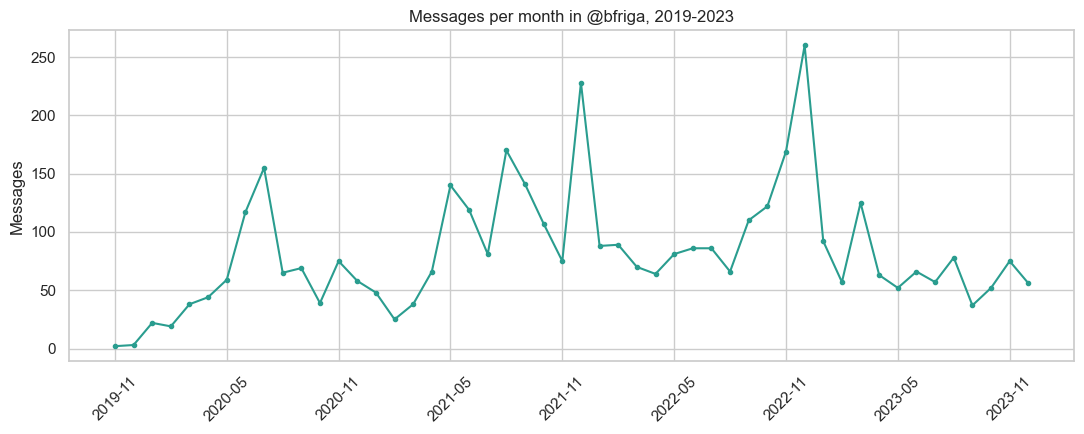

In [14]:
monthly = df.groupby("year_month").size()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly.values, marker="o", markersize=3, linewidth=1.5, color="#2a9d8f")
ax.set_title("Messages per month in @bfriga, 2019-2023")
ax.set_ylabel("Messages")
ax.set_xticks([monthly.index[i] for i in range(0, len(monthly), 6)])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/01_messages_per_month.png", dpi=150)
plt.show()

*notes:* not a straight growth line. climbs through 2020, then bursts around mid 2020 (about 155 in a month), may to aug 2021 (140-170) and two sharp winter spikes, around dec 2021 (roughly 230) and around dec 2022 (roughly 260). 2023 calms down to about 50-75 a month. looks more like seasons and campaigns than steady growth, need to check which categories cause the spikes.

### 4.2 hour of day by year

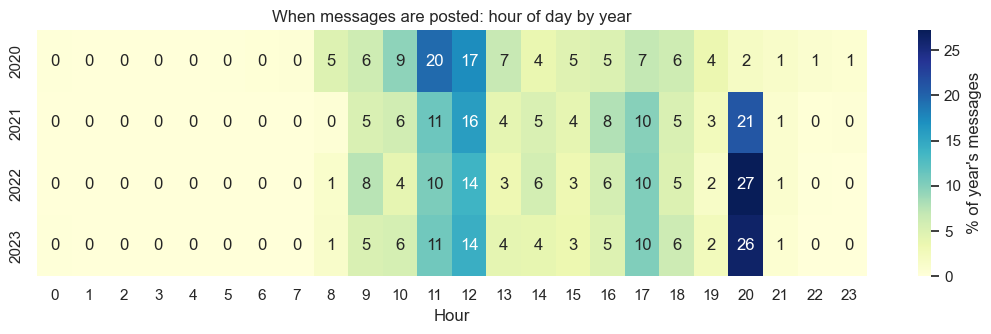

In [15]:
hour_year = pd.crosstab(main["year"], main["hour"], normalize="index") * 100
hour_year = hour_year.reindex(columns=range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(hour_year, cmap="YlGnBu", annot=True, fmt=".0f", cbar_kws={"label": "% of year's messages"}, ax=ax)
ax.set_title("When messages are posted: hour of day by year")
ax.set_xlabel("Hour")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/02_hour_by_year.png", dpi=150)
plt.show()

*notes:* 2020 is mostly midday, 11:00 and 12:00 together are about 37% of the year and 20:00 is only 2%. from 2021 a 20:00 slot shows up (21%) and grows to 27% in 2022 and 26% in 2023. 11:00 and 12:00 stay at roughly a quarter of posts, 17:00 holds around 10%. almost nothing between 21:00 and 07:00.

### 4.3 weekday by hour

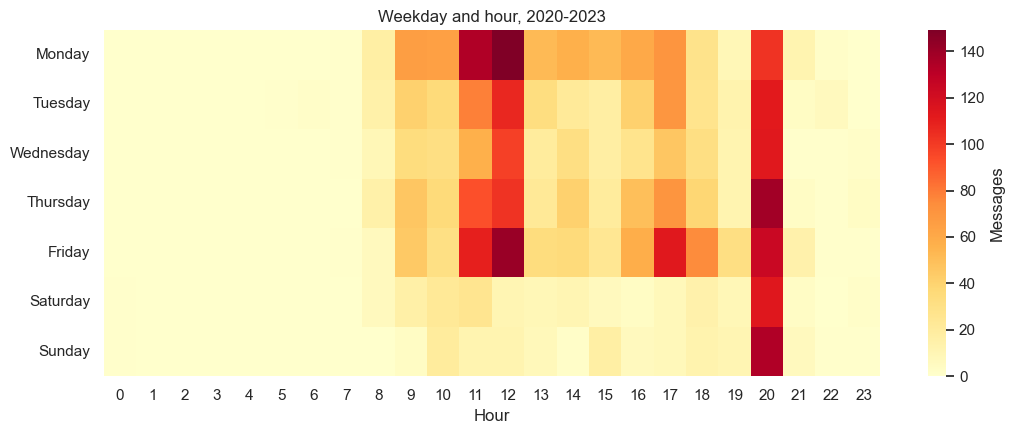

In [16]:
wd_hour = pd.crosstab(main["weekday"], main["hour"]).reindex(index=days, columns=range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(wd_hour, cmap="YlOrRd", cbar_kws={"label": "Messages"}, ax=ax)
ax.set_title("Weekday and hour, 2020-2023")
ax.set_xlabel("Hour")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/03_weekday_hour.png", dpi=150)
plt.show()

*notes:* 20:00 is hot every single day and it is pretty much the only hot spot on saturday and sunday. weekdays also have a late morning block at 11-12 (heaviest monday and friday) and a smaller one at 17:00 that is strongest on friday. wednesday is the quietest weekday, weekends are much lighter overall.

### 4.4 category mix by year

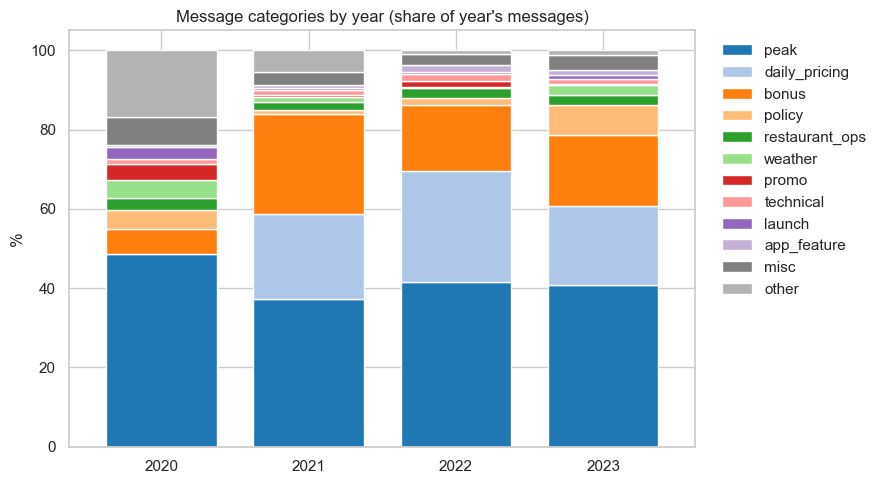

In [17]:
cat_year = pd.crosstab(main["year"], main["cat_plot"], normalize="index") * 100
cat_year = cat_year[[c for c in cat_order if c in cat_year.columns]]
fig, ax = plt.subplots(figsize=(9, 5))
cat_year.plot(kind="bar", stacked=True, color=[palette[c] for c in cat_year.columns], ax=ax, width=0.75)
ax.set_title("Message categories by year (share of year's messages)")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig("charts/04_category_by_year.png", dpi=150)
plt.show()

*notes:* 

### 4.5 language mix over time

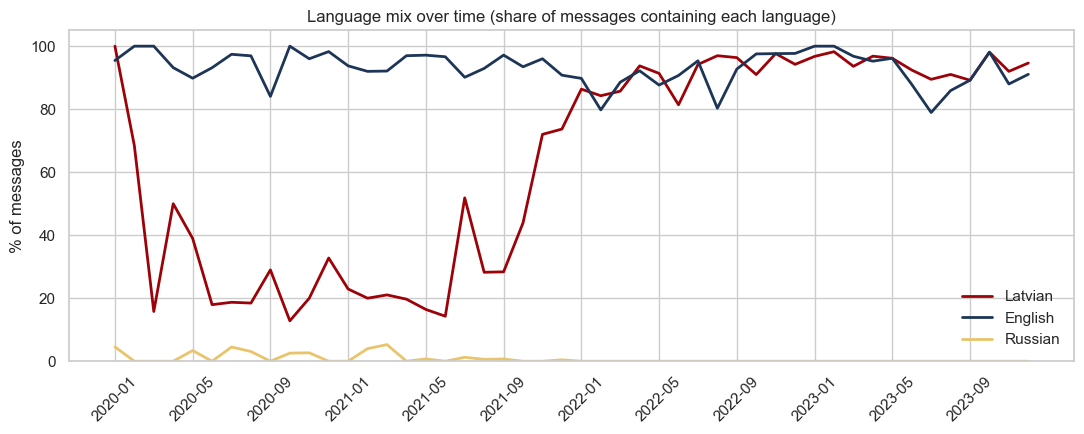

In [18]:
ym = main.groupby("year_month")
lang = ym[["has_lv", "has_ru", "has_en"]].mean() * 100
lang = lang[ym.size() >= 10]
fig, ax = plt.subplots(figsize=(11, 4.5))
for col, label, color in [("has_lv", "Latvian", "#9d0208"), ("has_en", "English", "#1d3557"), ("has_ru", "Russian", "#e9c46a")]:
    ax.plot(lang.index, lang[col], label=label, linewidth=2, color=color)
ax.set_title("Language mix over time (share of messages containing each language)")
ax.set_ylabel("% of messages")
ax.set_ylim(0, 105)
ax.set_xticks(lang.index[::4])
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("charts/05_language_mix.png", dpi=150)
plt.show()

*notes:* (months under 10 messages are dropped so the lines don't jump around on tiny samples) 

### 4.6 hour of day by category

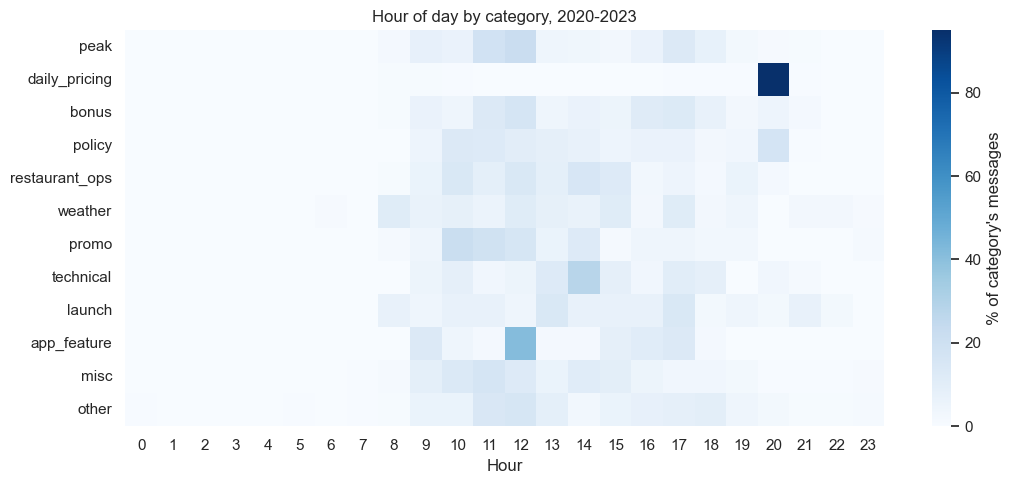

In [19]:
cat_hour = pd.crosstab(main["cat_plot"], main["hour"], normalize="index") * 100
cat_hour = cat_hour.reindex(columns=range(24), fill_value=0)
cat_hour = cat_hour.loc[[c for c in cat_order if c in cat_hour.index]]
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cat_hour, cmap="Blues", cbar_kws={"label": "% of category's messages"}, ax=ax)
ax.set_title("Hour of day by category, 2020-2023")
ax.set_xlabel("Hour")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/06_category_by_hour.png", dpi=150)
plt.show()

*notes:* 

### 4.7 monthly volume by category

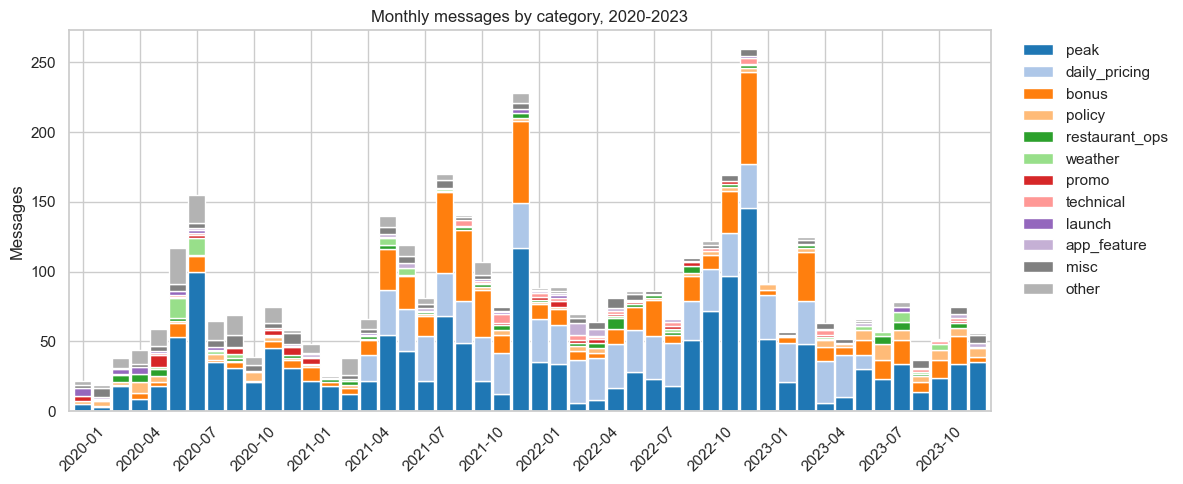

In [20]:
monthly_cat = pd.crosstab(main["year_month"], main["cat_plot"])
monthly_cat = monthly_cat[[c for c in cat_order if c in monthly_cat.columns]]
fig, ax = plt.subplots(figsize=(12, 5))
monthly_cat.plot(kind="bar", stacked=True, color=[palette[c] for c in monthly_cat.columns], ax=ax, width=0.9)
ax.set_title("Monthly messages by category, 2020-2023")
ax.set_xlabel("")
ax.set_ylabel("Messages")
ax.set_xticks(range(0, len(monthly_cat), 3))
ax.set_xticklabels(monthly_cat.index[::3], rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig("charts/07_monthly_volume_by_category.png", dpi=150)
plt.show()

*notes:* 

### 4.8 campaign cycles

when each campaign type is active. every row is scaled to its own busiest month so small categories like competition and launch are readable next to big ones like bonus. uses the raw categories, not the misc bucket.

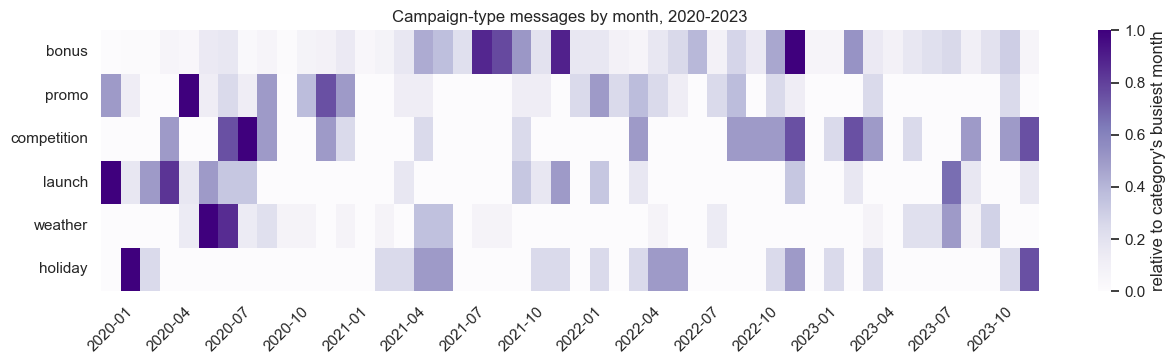

In [21]:
campaign_cats = ["bonus", "promo", "competition", "launch", "weather", "holiday"]
tab = pd.crosstab(main["year_month"], main["category"]).reindex(columns=campaign_cats, fill_value=0).T
scaled = tab.div(tab.max(axis=1).replace(0, 1), axis=0)
fig, ax = plt.subplots(figsize=(13, 3.8))
sns.heatmap(scaled, cmap="Purples", xticklabels=3, cbar_kws={"label": "relative to category's busiest month"}, ax=ax)
ax.set_title("Campaign-type messages by month, 2020-2023")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/08_campaign_cycles.png", dpi=150)
plt.show()

*notes:* 

## 5. headline numbers

In [22]:
share = (df["category"].value_counts(normalize=True) * 100).round(1)
templated = share.reindex(["peak", "daily_pricing", "bonus"]).fillna(0).sum()
print("Templated posts (peak + daily_pricing + bonus):", round(templated, 1), "% of messages")
print("Unclassified:", share.get("other", 0), "%")
print("Busiest hour:", df["hour"].value_counts().idxmax(), "-", df["hour"].value_counts().max(), "messages")
print("Busiest weekday:", df["weekday"].value_counts().idxmax())

Templated posts (peak + daily_pricing + bonus): 78.0 % of messages
Unclassified: 5.3 %
Busiest hour: 20 - 839 messages
Busiest weekday: Monday


## 6. limitations

- keyword classifier, so it misses unusual wording and can hit a keyword used in a different sense. that's also why categories under about 1% get lumped into misc in the charts.
- messages are multi-topic and trilingual so first-match is a simplification, `all_categories` has the full list.
- one-way broadcast channel, so this shows when bolt posted, not what couriers did.
- 2019 has 5 messages so it's left out of year comparisons.
- hour charts assume the timestamps are riga time (see the timezone check in section 1).